## 📐 Obstruction calculation


In [22]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import importlib

# Add current directory to path
if '.' not in sys.path:
    sys.path.insert(0, '.')

# Import and reload to get latest changes
import viz_utils
import sample_constructions
importlib.reload(viz_utils)
importlib.reload(sample_constructions)

from viz_utils import (HorizonAngleVisualizer, ZenithAngleVisualizer, 
                       CombinedObstructionVisualizer, DirectionVectorCalculator,
                       MeshExporter)
from sample_constructions import StandardScenarios

### 📡Setup Server Connection

Start the server: 

`python -m src.main`

In [ ]:
PROD = False
# Get token with: gcloud auth print-identity-token
API_TOKEN = None  # Paste your GCP token here when using PROD=True
SERVER_URL = "https://obstruction-server-jia3y72oka-ma.a.run.app" if PROD else "http://localhost:8081"

headers = {}
if API_TOKEN:
    headers["Authorization"] = f"Bearer {API_TOKEN}"

response = requests.get(f"{SERVER_URL}/", headers=headers)
print("Server Status:", response)

### 👉 Scenario construction

In [3]:
# Manual request construction example (new format)
window_center = [0.0, 3.0, 0.0]
direction_angle = 0.0  # Facing +X direction (0 rad = East)
building_dist, building_height, building_width = 10.0, 5.0, 10.0
mesh = [[10, 0.0, -5], [10, 5, -5], [10, 0.0, 5],
        [10, 0.0, 5], [10, 5, -5], [10, 5, 5]]

print(f"Window: {window_center}")
print(f"Direction: {direction_angle} rad (0° = East, facing +X)")
print(f"Mesh: {len(mesh)} vertices ({len(mesh)//3} triangles)")

Window: [0.0, 3.0, 0.0]
Direction: 0.0 rad (0° = East, facing +X)
Mesh: 6 vertices (2 triangles)


### 👉 Horizon angle

In [4]:
# Create vertical building scenario
scenario = StandardScenarios.vertical_building(
    window_height=3.0,
    building_distance=10.0,
    building_height=5.0,
    building_width=10.0
)

window_center = scenario.window_center
direction_angle = scenario.direction_angle
mesh = scenario.get_combined_mesh()

print(f"Window: {window_center}, Direction angle: {direction_angle:.4f} rad")
print(f"Building: 10.0m away, 5.0m tall, 10.0m wide")

Window: [0.0, 0.0, 3.0], Direction angle: 0.0000 rad
Building: 10.0m away, 5.0m tall, 10.0m wide


In [5]:
request_data = scenario.to_request_data()
response = requests.post(f"{SERVER_URL}/horizon_angle", json=request_data)
result = response.json()
print("Result:", result)

Result: {'error': 'Missing required field: rad_x', 'status': 'error'}


In [6]:
if result.get("status") == "success":
    data = result["data"]
    obstruction_degrees = data["obstruction_angle_degrees"]
    obstruction_radians = data["obstruction_angle_radians"]
    highest_point = data["highest_point"]
    
    # Create visualizer using new direction_angle format
    visualizer = HorizonAngleVisualizer(
        window_center=window_center,
        direction_angle=direction_angle,
        mesh_vertices=mesh,
        building_dimensions=(building_dist, building_height, building_width)
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, highest_point, obstruction_degrees)
    plt.tight_layout()
    plt.show()

### 👉 Zenith Angle Calculation

In [7]:
# Test zenith angle with the same building
response = requests.post(f"{SERVER_URL}/zenith_angle", json=request_data)
zenith_result = response.json()
print("Zenith Result:", zenith_result)

if zenith_result.get("status") == "success":
    data = zenith_result["data"]
    zenith_degrees = data["obstruction_angle_degrees"]
    zenith_radians = data["obstruction_angle_radians"]
    

Zenith Result: {'error': 'Missing required field: rad_x', 'status': 'error'}


### 👉 Overhead Obstruction Example

In [8]:
# Create horizontal overhead scenario
overhead_scenario = StandardScenarios.horizontal_overhead(
    window_height=3.0,
    roof_start=1.0,
    roof_end=5.0,
    roof_height=4.0,
    roof_width=14.0
)

overhead_request = overhead_scenario.to_request_data()
overhead_request["direction_angle"] = 0.2
# Calculate zenith angle
response = requests.post(f"{SERVER_URL}/zenith_angle", json=overhead_request)
overhead_result = response.json()

if overhead_result.get("status") == "success":
    data = overhead_result["data"]
    zenith_deg = data["obstruction_angle_degrees"]
    lowest_pt = data["highest_point"]
    
    print(f"Zenith Angle: {zenith_deg:.2f}°")
    if zenith_deg > 0:
        print(f"Furthest overhead point: ({lowest_pt['x']:.1f}, {lowest_pt['y']:.1f}, {lowest_pt['z']:.1f})")
    else:
        print("No overhead obstruction found on direction plane")
else:
    print("ERROR:", overhead_result.get("error"))

ERROR: Missing required field: rad_x


NameError: name 'lowest_pt' is not defined

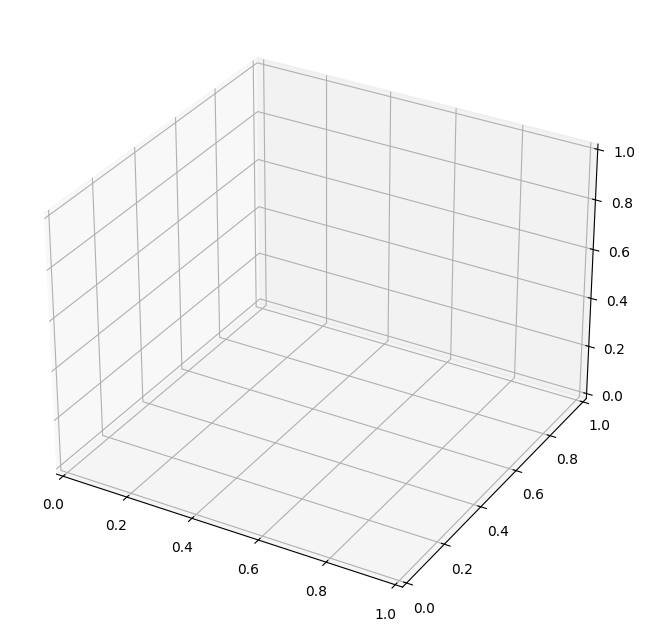

In [9]:
visualizer = ZenithAngleVisualizer(
    window_center=overhead_scenario.window_center,
    direction_angle=overhead_scenario.direction_angle,
    mesh_vertices=overhead_scenario.get_combined_mesh(),
    scene_dimensions=(8.0, 7.0, 4.0)
)

# Create figure and visualize
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
visualizer.visualize(ax, lowest_pt, zenith_deg)
plt.tight_layout()
plt.show()

### 👉 Obstruction (Both Angles)

Use the `/obstruction` endpoint to calculate both horizon and zenith angles in a single request.

In [10]:
# Create mixed scenario with both vertical and horizontal obstructions
mixed_scenario = StandardScenarios.mixed_obstruction(window_height=3.0)

# Get obstruction angles for both
response = requests.post(f"{SERVER_URL}/obstruction", json=mixed_scenario.to_request_data())
both_result = response.json()

In [11]:
if both_result.get("status") == "success":
    # Extract data
    horizon_data = both_result["data"]["horizon"]
    zenith_data = both_result["data"]["zenith"]
    
    # Create combined visualizer using new direction_angle format
    visualizer = CombinedObstructionVisualizer(
        window_center=mixed_scenario.window_center,
        direction_angle=mixed_scenario.direction_angle,
        mesh_vertices=mixed_scenario.get_combined_mesh()
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, horizon_data, zenith_data)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization - obstruction calculation failed")

Skipping visualization - obstruction calculation failed


### 👉 Real-World Data Example

Load and process a real window obstruction scenario from saved data.

In [12]:
# Import coordinate converter
import sys
if '.' not in sys.path:
    sys.path.insert(0, '.')

import coordinate_converter
importlib.reload(coordinate_converter)
from coordinate_converter import CoordinateConverter, convert_xzy_to_xyz, analyze_coordinates

import json

# Load real-world window data
sample_file = "window_4952383_request.json"
sample_path = f"../assets/sample2/{sample_file}"

with open(sample_path, 'r') as f:
    real_data = json.load(f)
    
# real_data["direction_angle"] = 3.14
# Convert to XYZ
corrected_data = real_data #convert_xzy_to_xyz(real_data)

In [13]:
corrected_data["direction_angle"] = 1.7

In [14]:
# Test with corrected XYZ coordinates
print("🔬 Testing with corrected XYZ coordinates:")
print("="*60)

# Send corrected data to API
response = requests.post(f"{SERVER_URL}/obstruction", json=corrected_data)
corrected_result = response.json()

if corrected_result.get("status") == "success":
    horizon_data = corrected_result["data"]["horizon"]
    zenith_data = corrected_result["data"]["zenith"]
    
    print(f"\n📊 Results with CORRECTED coordinates (XYZ):")
    print(f"   Horizon Angle: {horizon_data['obstruction_angle_degrees']:.2f}°")
    if horizon_data['highest_point']:
        hp = horizon_data['highest_point']
        print(f"   Highest point: ({hp['x']:.2f}, {hp['y']:.2f}, {hp['z']:.2f})")
    
    print(f"\n   Zenith Angle: {zenith_data['obstruction_angle_degrees']:.2f}°")
    if zenith_data['highest_point']:
        zp = zenith_data['highest_point']
        print(f"   Furthest overhead: ({zp['x']:.2f}, {zp['y']:.2f}, {zp['z']:.2f})")


print("="*60)

🔬 Testing with corrected XYZ coordinates:


NameError: name 'horizon_data' is not defined

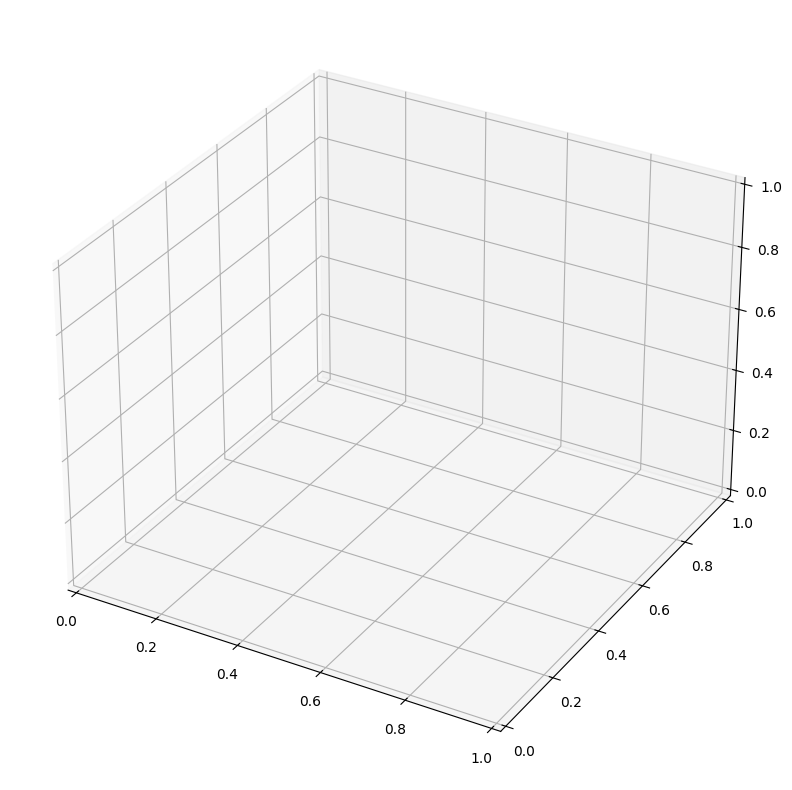

In [15]:

visualizer = CombinedObstructionVisualizer(
    window_center=[corrected_data['x'], corrected_data['y'], corrected_data['z']],
    direction_angle=corrected_data['direction_angle'],
    mesh_vertices=corrected_data['mesh'][:3000]
)

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
visualizer.visualize(ax, horizon_data, zenith_data)
plt.tight_layout()
plt.show()

In [16]:
h_data = corrected_result["data"]["horizon"]
z_data = corrected_result["data"]["zenith"]
fig = plt.figure(figsize=(18, 12))
    
# Define different viewing angles (elevation, azimuth)
views = [
    (90, 0, "Top View (XZ)")
]

for idx, (elev, azim, title) in enumerate(views, 1):
    ax = fig.add_subplot(1, 1, idx, projection='3d')
    
    # Create visualizer for each subplot using direction_angle
    # Note: corrected_data['rad_y'] = 0.0, which is the direction_angle
    visualizer = CombinedObstructionVisualizer(
        window_center=[corrected_data['x'], corrected_data['y'], corrected_data['z']],
        direction_angle=corrected_data['direction_angle'],  # rad_y=0.0 (facing +X)
        mesh_vertices=corrected_data['mesh'][:3000]
    )
    
    visualizer.visualize(ax, h_data, z_data)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

KeyError: 'data'

In [17]:
h_data = corrected_result["data"]["horizon"]
z_data = corrected_result["data"]["zenith"]
fig = plt.figure(figsize=(18, 12))
    
# Define different viewing angles (elevation, azimuth)
views = [
    (30, 45, "Perspective View"),
    (30, 135, "Front View (XY)"),
    (0, -90, "Side View (YZ)"),
    (90, 0, "Top View (XZ)")
]

for idx, (elev, azim, title) in enumerate(views, 1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    
    # Create visualizer for each subplot using direction_angle
    # Note: corrected_data['rad_y'] = 0.0, which is the direction_angle
    visualizer = CombinedObstructionVisualizer(
        window_center=[corrected_data['x'], corrected_data['y'], corrected_data['z']],
        direction_angle=corrected_data['direction_angle'],  # rad_y=0.0 (facing +X)
        mesh_vertices=corrected_data['mesh'][:3000]
    )
    
    visualizer.visualize(ax, h_data, z_data)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

KeyError: 'data'

### 💾 Export Mesh to OBJ File

Export the mesh data to a Wavefront OBJ file for use in 3D modeling software (Blender, Maya, etc.)

In [13]:
# Export the real-world mesh to OBJ format
output_filename = f"../assets/exports/{sample_file.replace('.json', '.obj')}"

# Create exports directory if it doesn't exist
import os
os.makedirs("../assets/exports", exist_ok=True)

# Export mesh with window position in header
MeshExporter.to_obj(
    mesh_vertices=real_data['mesh'],
    output_path=output_filename,
    window_center=[real_data['x'], real_data['y'], real_data['z']]
)

print(f"✅ Exported mesh to: {output_filename}")
print(f"   Vertices: {len(real_data['mesh']):,}")
print(f"   Triangles: {len(real_data['mesh']) // 3:,}")
print(f"\nYou can now open this file in Blender, MeshLab, or any 3D viewer!")

✅ Exported mesh to: ../assets/exports/window_4952361_request.obj
   Vertices: 117,018
   Triangles: 39,006

You can now open this file in Blender, MeshLab, or any 3D viewer!


### 👉 Parallel Multi-Direction Obstruction Calculation

Calculate obstruction angles for 64 directions simultaneously.

In [26]:
# Create scenario for parallel testing
parallel_scenario = StandardScenarios.vertical_building(
    window_height=1.5, building_distance=5.0, building_height=3.0, building_width=10.0
)

parallel_request = parallel_scenario.to_request_data()
parallel_request["microservice_url"] = f"{SERVER_URL}/obstruction"
parallel_request["num_directions"] = 64

# Add API token if configured
if API_TOKEN:
    parallel_request["auth_token"] = API_TOKEN

print(f"Window: ({parallel_request['x']}, {parallel_request['y']}, {parallel_request['z']})")
print(f"Directions: {parallel_request['num_directions']}")

Window: (0.0, 0.0, 1.5)
Directions: 64


In [ ]:
import time

# Prepare headers with authorization if API_TOKEN is set
headers = {"Content-Type": "application/json"}
if API_TOKEN:
    headers["Authorization"] = f"Bearer {API_TOKEN}"

response = requests.post(f"{SERVER_URL}/obstruction_parallel", json=parallel_request, headers=headers)
parallel_result = response.json()

if parallel_result.get("status") == "success":
    data = parallel_result["data"]
    print(f"Directions: {data['num_directions']}, Time: {data['total_time_seconds']:.2f}s")
    print(f"Horizon angles: {data['horizon_angles'][:5]}...")
else:
    print(f"Error: {parallel_result.get('error')}")

In [ ]:
# Create scenario for parallel testing
parallel_scenario = StandardScenarios.vertical_building(
    window_height=1.5, building_distance=5.0, building_height=3.0, building_width=10.0
)

parallel_request = parallel_scenario.to_request_data()
parallel_request["num_directions"] = 64

# microservice_url is no longer needed - calculations run directly in parallel

print(f"Window: ({parallel_request['x']}, {parallel_request['y']}, {parallel_request['z']})")
print(f"Directions: {parallel_request['num_directions']}")

In [ ]:
# Polar plot visualization
if parallel_result.get("status") == "success":
    data = parallel_result["data"]
    theta = np.radians(data['direction_angles_degrees'])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection='polar'))
    
    ax1.plot(theta, data['horizon_angles'], 'b-', linewidth=2)
    ax1.fill(theta, data['horizon_angles'], alpha=0.3)
    ax1.set_title('Horizon Obstruction', fontweight='bold', pad=20)
    
    ax2.plot(theta, data['zenith_angles'], 'r-', linewidth=2)
    ax2.fill(theta, data['zenith_angles'], alpha=0.3, color='red')
    ax2.set_title('Zenith Obstruction', fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Visualize the results as a polar plot
if parallel_result.get("status") == "success":
    data = parallel_result["data"]
    horizon_angles = np.array(data['horizon_angles'])
    zenith_angles = np.array(data['zenith_angles'])
    direction_angles = np.array(data['direction_angles_degrees'])
    
    # Convert direction angles to radians for polar plot
    # Adjust angles for polar plot (0° at top, clockwise)
    theta = np.radians(direction_angles)
    
    # Create polar plot
    fig = plt.figure(figsize=(16, 7))
    
    # Horizon angles plot
    ax1 = fig.add_subplot(121, projection='polar')
    ax1.plot(theta, horizon_angles, 'b-', linewidth=2, label='Horizon Obstruction')
    ax1.fill(theta, horizon_angles, alpha=0.3, color='blue')
    ax1.set_theta_zero_location('N')
    ax1.set_theta_direction(-1)
    ax1.set_title('Horizon Obstruction Angles\n(360° View Around Window)', 
                  fontsize=12, fontweight='bold', pad=20)
    ax1.set_ylabel('Obstruction Angle (degrees)', labelpad=30)
    ax1.grid(True)
    ax1.legend(loc='upper right')
    
    # Zenith angles plot
    ax2 = fig.add_subplot(122, projection='polar')
    ax2.plot(theta, zenith_angles, 'r-', linewidth=2, label='Zenith Obstruction')
    ax2.fill(theta, zenith_angles, alpha=0.3, color='red')
    ax2.set_theta_zero_location('N')
    ax2.set_theta_direction(-1)
    ax2.set_title('Zenith Obstruction Angles\n(360° View Around Window)', 
                  fontsize=12, fontweight='bold', pad=20)
    ax2.set_ylabel('Zenith Angle (degrees)', labelpad=30)
    ax2.grid(True)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\n📈 Obstruction Statistics:")
    print(f"\n   Horizon Angles:")
    print(f"      Min: {np.min(horizon_angles):.2f}°")
    print(f"      Max: {np.max(horizon_angles):.2f}°")
    print(f"      Mean: {np.mean(horizon_angles):.2f}°")
    print(f"      Std: {np.std(horizon_angles):.2f}°")
    
    print(f"\n   Zenith Angles:")
    print(f"      Min: {np.min(zenith_angles):.2f}°")
    print(f"      Max: {np.max(zenith_angles):.2f}°")
    print(f"      Mean: {np.mean(zenith_angles):.2f}°")
    print(f"      Std: {np.std(zenith_angles):.2f}°")

In [ ]:
# Send parallel obstruction request
import time

print("\n🚀 Sending parallel request...")
start_time = time.time()

response = requests.post(f"{SERVER_URL}/obstruction_parallel", json=parallel_request)
parallel_result = response.json()

elapsed = time.time() - start_time

if parallel_result.get("status") == "success":
    data = parallel_result["data"]
    
    print(f"✅ Parallel calculation completed!")
    print(f"\n📊 Results Summary:")
    print(f"   Total directions: {data['num_directions']}")
    print(f"   Total time: {data['total_time_seconds']:.2f}s")
    print(f"   Client elapsed: {elapsed:.2f}s")
    print(f"   Avg time per direction: {data['total_time_seconds']/data['num_directions']*1000:.1f}ms")
    
    # Show sample of horizon angles
    horizon_angles = data['horizon_angles']
    zenith_angles = data['zenith_angles']
    direction_angles = data['direction_angles_degrees']
    
    print(f"\n   Horizon angles (first 5 directions):")
    for i in range(min(5, len(horizon_angles))):
        print(f"      Direction {direction_angles[i]:.1f}°: {horizon_angles[i]:.2f}°")
    
    print(f"\n   Zenith angles (first 5 directions):")
    for i in range(min(5, len(zenith_angles))):
        print(f"      Direction {direction_angles[i]:.1f}°: {zenith_angles[i]:.2f}°")
else:
    print(f"❌ Error: {parallel_result.get('error', 'Unknown error')}")

In [20]:
# Create a simple scenario for parallel testing
parallel_scenario = StandardScenarios.vertical_building(
    window_height=1.5,
    building_distance=5.0,
    building_height=3.0,
    building_width=10.0
)

# Prepare request for parallel calculation
parallel_request = parallel_scenario.to_request_data()

# Add microservice URL (this should point to your deployed obstruction service)
# For local testing, use the same server
parallel_request["microservice_url"] = f"{SERVER_URL}/obstruction"

# Optional: Customize number of directions and angle range
parallel_request["num_directions"] = 64
parallel_request["start_angle_degrees"] = 17.5
parallel_request["end_angle_degrees"] = 162.5

# Optional: Add GCP authentication token if using Cloud Run
# parallel_request["auth_token"] = "your-gcp-bearer-token"

print("📡 Parallel Request Configuration:")
print(f"   Window: ({parallel_request['x']}, {parallel_request['y']}, {parallel_request['z']})")
print(f"   Mesh vertices: {len(parallel_request['mesh'])}")
print(f"   Directions: {parallel_request['num_directions']}")
print(f"   Angle range: {parallel_request['start_angle_degrees']}° to {parallel_request['end_angle_degrees']}°")
print(f"   Microservice URL: {parallel_request['microservice_url']}")

📡 Parallel Request Configuration:
   Window: (0.0, 0.0, 1.5)
   Mesh vertices: 6
   Directions: 64
   Angle range: 17.5° to 162.5°
   Microservice URL: https://obstruction-server-jia3y72oka-ma.a.run.app/obstruction
